# Relational operators comparison (overall)
This notebook compares overall Top-1 accuracy across layers for three relational operators: Bilinear, Translational, and LRE.

We group runs using `train_df` into:
- Reversal Cursed (G1): reverse_uni_acc < 0.4
- Not Reversal Cursed (G2): reverse_uni_acc > 0.98

The final figure overlays all methods and both groups in a single plot (hue = method, style = group).

In [9]:
# Imports
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from utils import load_results
# Load three operators
# df_bilinear = load_results("../results/roh", "roh_bilinear_accuracy*.json")
df_bilinear = load_results("../results/rescal", "rescal_accuracy*.json")
df_translation = load_results("../results/translation", "roh_translational_accuracy*.json")
df_bilinear = df_bilinear[df_bilinear["layer"] > 0 ]
df_translation  = df_translation[df_translation["layer"] > 0 ]
df_lre = load_results("../results/lre_jacobian", "*.json")
df_lre = df_lre[df_lre["beta"] == 5.0]  # Exclude beta=2.0 for clarity
df_lre["layer"] = df_lre["layer"] + 1
# Optional training meta (for consistency or future grouping)
try:
    train_df = pd.read_json("../results/training/aggregated_results.json")
    train_df = train_df.rename(columns={"weight_decay": "wd"})
except Exception:
    train_df = None

# Style
sns.set_theme(style="ticks")
print("Loaded:", len(df_bilinear), len(df_translation), len(df_lre))

Loaded: 2916 2916 2916


In [10]:
# Group runs into G1/G2 via train_df like other notebooks
threshold_low = 0.4
threshold_high = 0.98

if train_df is None or train_df.empty:
    raise ValueError("train_df is required for grouping but is missing or empty.")

mask_g1 = (train_df['reverse_uni_acc'] < threshold_low)
mask_g2 = train_df['reverse_uni_acc'] > threshold_high

g1_runs = train_df[mask_g1][['wd', 'seed']]
g2_runs = train_df[mask_g2][['wd', 'seed']]

g1_tuples = set(zip(g1_runs['wd'], g1_runs['seed']))
g2_tuples = set(zip(g2_runs['wd'], g2_runs['seed']))

def add_group(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0 or not {'wd','seed'}.issubset(df.columns):
        return pd.DataFrame(columns=df.columns.tolist() + ['group']) if df is not None else pd.DataFrame(columns=['group'])
    df_g1 = df[df[['wd','seed']].apply(tuple, axis=1).isin(g1_tuples)].copy()
    df_g2 = df[df[['wd','seed']].apply(tuple, axis=1).isin(g2_tuples)].copy()
    df_g1['group'] = 'Reversal Cursed'
    df_g2['group'] = 'Not Reversal Cursed'
    return pd.concat([df_g1, df_g2], ignore_index=True)

df_bilinear_g = add_group(df_bilinear)
df_translation_g = add_group(df_translation)
df_lre_g = add_group(df_lre)

print({
    'bilinear_rows': len(df_bilinear_g) if df_bilinear_g is not None else 0,
    'translation_rows': len(df_translation_g) if df_translation_g is not None else 0,
    'lre_rows': len(df_lre_g) if df_lre_g is not None else 0,
})

{'bilinear_rows': 2376, 'translation_rows': 2376, 'lre_rows': 2376}


In [11]:
# Aggregate 'overall' per layer and group for each method
def overall_by_layer_grouped(df, acc_col="accuracy", relation_col="relation"):
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=["layer","group","accuracy","seed", "wd"])
    d = df.copy()
    if relation_col in d.columns:
        d = d[d[relation_col] == "overall"].copy()
    if "layer" not in d.columns or "group" not in d.columns:
        return pd.DataFrame(columns=["layer","group","accuracy","seed","wd"])
    return (d.groupby(["group","layer","seed","wd"], as_index=False)[acc_col].mean())

bilinear_grp = overall_by_layer_grouped(df_bilinear_g)
trans_grp = overall_by_layer_grouped(df_translation_g)
lre_grp = overall_by_layer_grouped(df_lre_g)

bilinear_grp["method"] = "Bilinear"
trans_grp["method"] = "Translational"
lre_grp["method"] = "LRE"

df_comp_grp = pd.concat([bilinear_grp, trans_grp, lre_grp], ignore_index=True)
df_comp_grp = df_comp_grp.sort_values(["group","method","layer"])
df_comp_grp.head()

,group,layer,seed,wd,accuracy,method
0,Not Reversal Cursed,1,0,3.0,0.194667,Bilinear
1,Not Reversal Cursed,1,0,4.0,0.178333,Bilinear
2,Not Reversal Cursed,1,0,5.0,0.181500,Bilinear
3,Not Reversal Cursed,1,0,6.0,0.186167,Bilinear
4,Not Reversal Cursed,1,1,6.0,0.179000,Bilinear


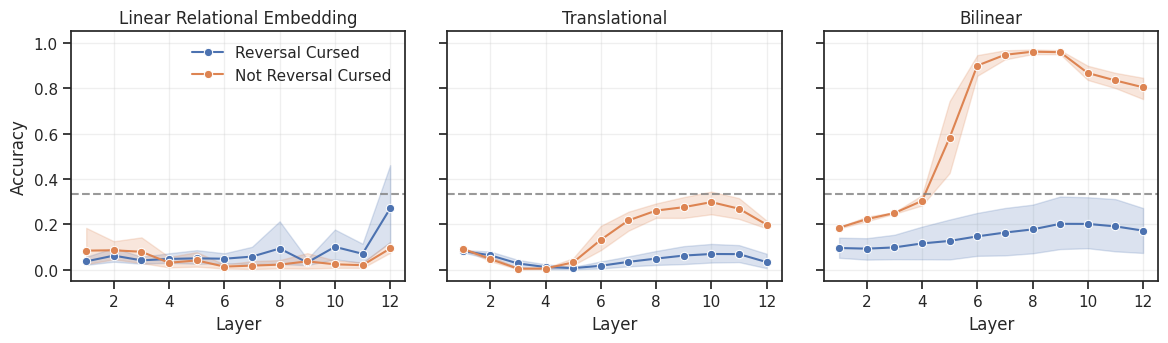

In [19]:
# 1x3 subplots: one per method, comparing groups
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)

method_dfs = [
    ("Linear Relational Embedding", lre_grp),
    ("Translational", trans_grp),
    ("Bilinear", bilinear_grp),
]

for ax, (name, dfm) in zip(axes, method_dfs):
    sns.lineplot(
        data=dfm,
        x="layer",
        y="accuracy",
        hue="group",
        hue_order=['Reversal Cursed', 'Not Reversal Cursed'],
        # palette=group_colors,
        marker="o",
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.axhline(1/3, linestyle="--", color="gray", linewidth=1.5, alpha=0.8)
    if name != "Linear Relational Embedding":
        ax.legend_.remove()
    else:
        ax.legend(loc='upper right', frameon=False)

# Single shared legend (bottom-center)
plt.tight_layout()
# plt.show()
plt.savefig("embedding_results.pdf", bbox_inches='tight')

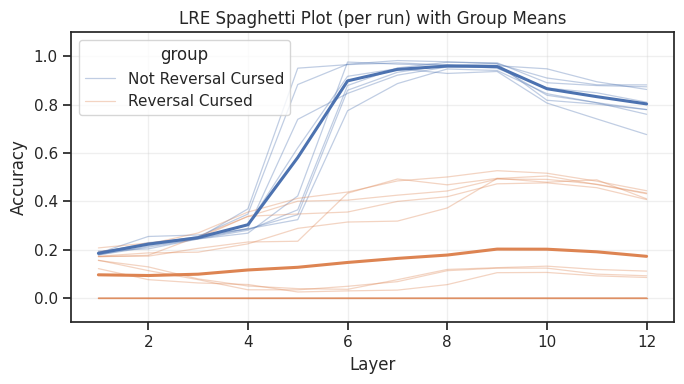

In [13]:
# Spaghetti plot for LRE: one line per (wd, seed), colored by group, with bold group means
lre_sp = bilinear_grp.copy()
lre_sp["run"] = lre_sp["wd"].astype(str) + "-s" + lre_sp["seed"].astype(str)

fig_sp, ax_sp = plt.subplots(figsize=(7, 4))
sns.lineplot(
    data=lre_sp,
    x="layer",
    y="accuracy",
    hue="group",
    units="run",
    estimator=None,
    alpha=0.35,
    lw=0.9,
    ax=ax_sp,
)

# Overlay group means as thicker lines
lre_mean = lre_sp.groupby(["group", "layer"], as_index=False)["accuracy"].mean()
sns.lineplot(
    data=lre_mean,
    x="layer",
    y="accuracy",
    hue="group",
    lw=2.2,
    legend=False,  # keep legend from the spaghetti layer
    ax=ax_sp,
)

ax_sp.set_title("LRE Spaghetti Plot (per run) with Group Means")
ax_sp.set_xlabel("Layer")
ax_sp.set_ylabel("Accuracy")
ax_sp.set_ylim(-0.1, 1.1)
ax_sp.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

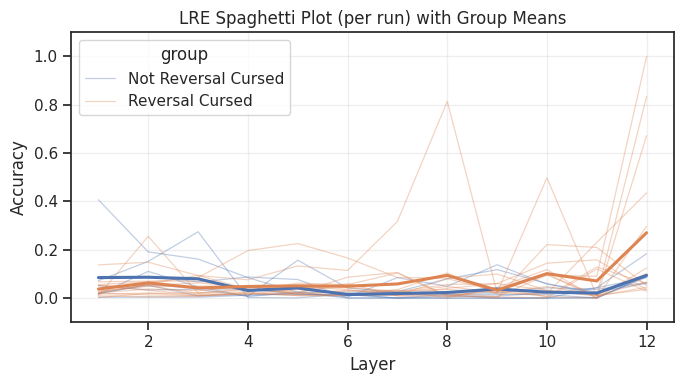

In [14]:
# Spaghetti plot for LRE: one line per (wd, seed), colored by group, with bold group means
lre_sp = lre_grp.copy()
lre_sp["run"] = lre_sp["wd"].astype(str) + "-s" + lre_sp["seed"].astype(str)

fig_sp, ax_sp = plt.subplots(figsize=(7, 4))
sns.lineplot(
    data=lre_sp,
    x="layer",
    y="accuracy",
    hue="group",
    units="run",
    estimator=None,
    alpha=0.35,
    lw=0.9,
    ax=ax_sp,
)

# Overlay group means as thicker lines
lre_mean = lre_sp.groupby(["group", "layer"], as_index=False)["accuracy"].mean()
sns.lineplot(
    data=lre_mean,
    x="layer",
    y="accuracy",
    hue="group",
    lw=2.2,
    legend=False,  # keep legend from the spaghetti layer
    ax=ax_sp,
)

ax_sp.set_title("LRE Spaghetti Plot (per run) with Group Means")
ax_sp.set_xlabel("Layer")
ax_sp.set_ylabel("Accuracy")
ax_sp.set_ylim(-0.1, 1.1)
ax_sp.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

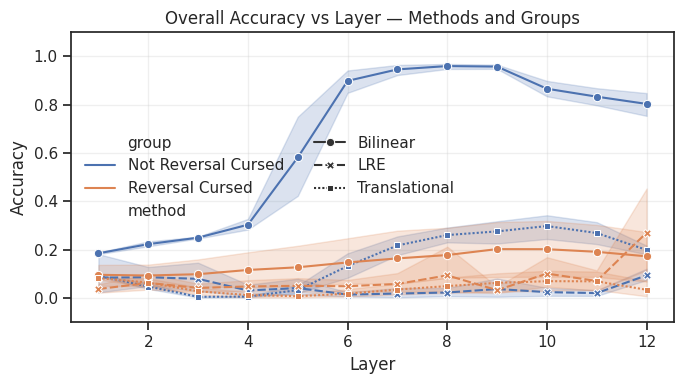

In [15]:
# Single-figure overlay: methods (hue) and groups (style)
d = df_comp_grp.copy()
plt.figure(figsize=(7, 4))
    # Create custom palette to ensure consistent colors for groups
# group_colors = {'Reversal Cursed': 'C0', 'Not Reversal Cursed': 'C1'}

sns.lineplot(data=d, x="layer", y="accuracy", hue="group", style="method", 
            markers=True, dashes=True)
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.title("Overall Accuracy vs Layer — Methods and Groups")
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)
plt.legend(title=None, frameon=False, ncols=2)
plt.tight_layout()
plt.show()